In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
import orbitize
from orbitize.results import Results
import numpy as np
import matplotlib.pyplot as plt
import corner
from astropy.time import Time

In [2]:

plt.rcParams.update({
    "text.usetex": True,  
    "font.family": "Fira Sans",  
    "font.size": 16,
    "axes.labelsize": 16,    
    "xtick.labelsize": 14,   
    "ytick.labelsize": 14,   
    "legend.fontsize": 13
})

In [3]:
files = {
    "RV + yes_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5",
    "RV_better + yes_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_yes_gravity.hdf5",
    "no_RV + yes_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_yes_gravity.hdf5",
    "no_RV + no_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_no_gravity.hdf5",
    "RV + no_grav": "/Users/astrovidee/Dropbox//GQ_lup_b_analysis/new_runs/new_run_RV_no_gravity.hdf5",
    "RV_better + no_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_no_gravity.hdf5"
}


In [ ]:
#Figure 1
# Color map for orbit lines
cmap = plt.cm.Blues

for label, path in files.items():
    print(f"Plotting orbits for: {label}")
    
    results = Results()
    results.load_results(path)
    sort_order = np.argsort(results.system.data_table['epoch'])
    for col in results.system.data_table.colnames:
        results.system.data_table[col] = results.system.data_table[col][sort_order]


    epochs = results.system.data_table['epoch']
    mtot_idx = results.standard_param_idx.pop('mtot')
    results.standard_param_idx['m0'] = mtot_idx
    results.standard_param_idx['mtot'] = mtot_idx
    orbit_fig = results.plot_orbits(
        object_to_plot=1,
        num_orbits_to_plot=100,
        start_mjd=np.min(epochs) - 100,
        rv_time_series=True,
        show_colorbar=True,
        cmap=cmap,
    )

    ax = orbit_fig.axes[0]
    
    # Plot the star
    ax.scatter(0, 0, marker='*', color='gold', s=300, zorder=10)
    
    # Set axis limits
    ax.set_xlim(2000, -2000)
    ax.set_ylim(-2000, 2000)
    
    # Add direction labels
    ax.text(0.95, 0.95, "North ↑", transform=ax.transAxes, ha='right', va='top', fontsize=14)
    ax.text(0.95, 0.90, "East \u2190", transform=ax.transAxes, ha='right', va='top', fontsize=14)
    



    sep_ax = orbit_fig.axes[1]
    pa_ax = orbit_fig.axes[2]



    gravity_mask = ['GRAVITY' in str(inst).strip().upper() for inst in results.system.data_table['instrument']]
    radec_mask = [str(qt).strip().lower() == 'radec' if qt is not None else False for qt in results.system.data_table['quant_type']]

    gravity_points = results.system.data_table[np.logical_and(gravity_mask, radec_mask)]
    other_points = results.system.data_table[np.logical_and(np.logical_not(gravity_mask), radec_mask)]

    if len(gravity_points) > 0:
        sep = np.sqrt(gravity_points['quant1']**2 + gravity_points['quant2']**2)
        pa = (np.degrees(np.arctan2(gravity_points['quant1'], gravity_points['quant2'])) + 360) % 360
        epoch_yr = Time(gravity_points['epoch'], format='mjd').decimalyear
        sep_ax.scatter(epoch_yr, sep, s=40, marker='s', facecolor='red', edgecolors='k', label='New GRAVITY points', zorder=20)
        pa_ax.scatter(epoch_yr, pa, s=40, marker='s', facecolor='red', edgecolors='k', label='New GRAVITY points', zorder=20)

    if len(other_points) > 0:
        sep = np.sqrt(other_points['quant1']**2 + other_points['quant2']**2)
        pa = (np.degrees(np.arctan2(other_points['quant1'], other_points['quant2'])) + 360) % 360
        epoch_yr = Time(other_points['epoch'], format='mjd').decimalyear
        sep_ax.scatter(epoch_yr, sep, s=40, marker='o', color='red', label='Non-GRAVITY points', zorder=15)
        pa_ax.scatter(epoch_yr, pa, s=40, marker='o', color='red', label='Non-GRAVITY points', zorder=15)

    # Axis labels
    sep_ax.set_xlabel("Epoch [yr]", fontsize=14)
    sep_ax.set_ylabel("Separation [mas]", fontsize=14)
    pa_ax.set_xlabel("Epoch [yr]", fontsize=14)
    pa_ax.set_ylabel("Position Angle [deg]", fontsize=14)

    # Legends
    sep_ax.legend(loc='best', fontsize=12)
    pa_ax.legend(loc='best', fontsize=12)
    #ax.legend(loc='upper left', fontsize=10)

    # Save figure as PDF for Overleaf
    fname = f"orbit_plot_{label.replace(' ', '_').replace('+', 'plus')}.pdf"
    plt.savefig(fname, format='pdf', bbox_inches='tight')
    plt.close()

print("All orbit plots generated and saved.")


Plotting orbits for: RV + yes_grav


/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:249: UserWarning: It seems that the stellar and companion mass have not been fitted separately. Setting rv_time_series=True is therefore not possible so the argument is set to False instead.
  warnings.warn(
/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:1061: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:1061: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Plotting orbits for: RV_better + yes_grav


/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:249: UserWarning: It seems that the stellar and companion mass have not been fitted separately. Setting rv_time_series=True is therefore not possible so the argument is set to False instead.
  warnings.warn(
/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:1061: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/astrovidee/anaconda3/envs/codeastro/lib/python3.10/site-packages/orbitize/plot.py:1061: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Plotting orbits for: no_RV + yes_grav


...

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

In [5]:
#Figure 2
files = {
    "RV + yes_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5",
}
# Parameters to show in the corner plot
param_list = ["sma1", "ecc1", "inc1", "aop1", "pan1", "tau1", "plx", "mtot"]


default_labels = {
    "sma": "$a_{0}$ [au]",
    "ecc": "$ecc_{0}$",
    "inc": "$inc_{0}$ [$^\\circ$]",
    "aop": "$\\omega_{0}$ [$^\\circ$]",
    "pan": "$\\Omega_{0}$ [$^\\circ$]",
    "tau": "$\\tau_{0}$",
    "plx": "$\\pi$ [mas]",
    "mtot": "$M_T$ [M$_{\\odot}$]",
}
ranges = [
    (80, 160),      # sma1
    (0, 1),         # ecc1
    (0, 60),       # inc1
    (80, 250),       # aop1
    (160, 330),       # pan1
    (0, 0.6),         # tau1
    (6.30, 6.7),        # plx
    (0.59, 1.4),         # mtot
]

for label, filepath in files.items():
    print(f"Processing: {label}")
    
    results = Results()
    results.load_results(filepath)
    
    # Extract relevant parameters
    param_indices = [results.param_idx[p] for p in param_list]
    samples = results.post[:, param_indices]

    # Convert angles from radians to degrees
    angle_indices = [i for i, p in enumerate(param_list) if p.startswith(("aop", "pan", "inc"))]
    samples[:, angle_indices] = np.degrees(samples[:, angle_indices])

    # Compute medians and errors
    medians = np.median(samples, axis=0)
    lowers = np.percentile(samples, 16, axis=0)
    uppers = np.percentile(samples, 84, axis=0)
    errors_minus = medians - lowers
    errors_plus = uppers - medians

    # Build labels
    labels = [default_labels[''.join([c for c in p if not c.isdigit()])] for p in param_list]

    # Generate corner plot
    fig = corner.corner(samples, labels=labels, bins=25, plot_datapoints=True,
                        plot_density=True, fill_contours=True, color='#0072B2', ranges=ranges)

    # Annotate medians + 1σ
    ndim = len(param_list)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        ax = axes[i, i]
        pos = ax.get_position()
        txt = r"${0:.3f}_{{-{1:.3f}}}^{{+{2:.3f}}}$".format(
            medians[i], errors_minus[i], errors_plus[i]
        )
        fig.text(0.5 * (pos.x0 + pos.x1), pos.y1 + 0.005, txt,
                 ha="center", va="bottom", fontsize=18)

    # Save the figure for Overleaf
    fname = f"corner_plot_{label.replace(' ', '_').replace('+', 'plus')}.pdf"
    plt.savefig(fname, bbox_inches='tight')
    plt.close()

print("All corner plots saved.")


Processing: RV + yes_grav


All corner plots saved.


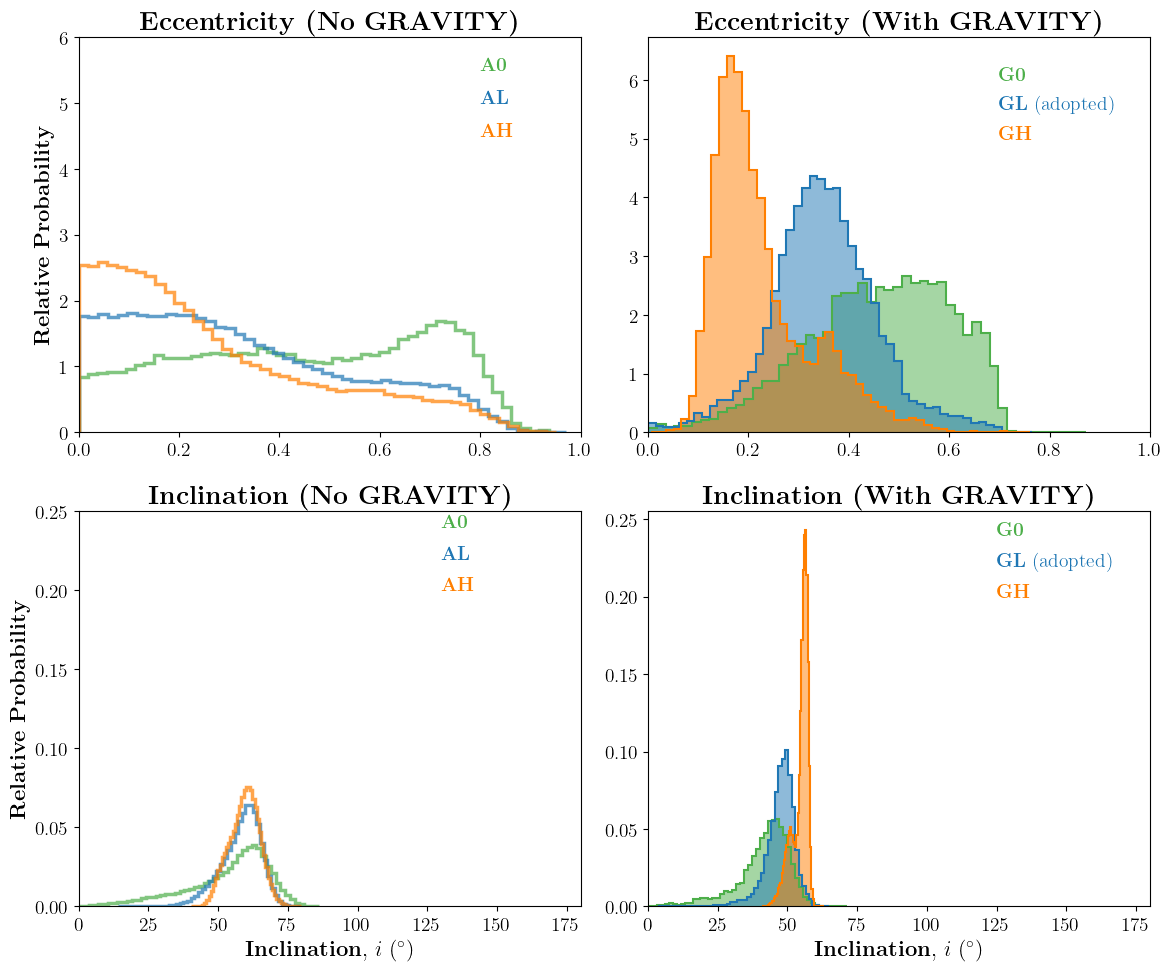

In [ ]:
#Figure 3
files = {
    "GL": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5",
    "GH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_yes_gravity.hdf5",
    "G0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_yes_gravity.hdf5",
    "A0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_no_gravity.hdf5",
    "AL": "/Users/astrovidee/Dropbox//GQ_lup_b_analysis/new_runs/new_run_RV_no_gravity.hdf5",
    "AH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_no_gravity.hdf5"
}
# Load eccentricity & inclination posteriors
ecc_data, inc_data = {}, {}
for label, file_path in files.items():
    with h5py.File(file_path, 'r') as f:
        data = f['post'][:]
        ecc_data[label] = data[:, 1]
        inc_data[label] = (data[:, 2] * u.rad).to(u.deg).value

# Color map
colors = {
    "no_RV": "#4daf4a",   # Green
    "low_RV": "#1f77b4",  # Blue
    "high_RV": "#ff7f00"  # Orange
}

rv_map = {
    "A0": ("no_RV", "solid"),
    "G0": ("no_RV", "solid"),
    "AL": ("low_RV", "solid"),
    "GL": ("low_RV", "solid"),
    "AH": ("high_RV", "solid"),
    "GH": ("high_RV", "solid")
}
label_positions = {
    "A0": (0.8, 5.5),
    "AL": (0.8, 5.0),
    "AH": (0.8, 4.5),
    "G0": (0.7, 6.0),
    "GL": (0.7, 5.5),
    "GH": (0.7, 5.0),
}


# 4 panel figure
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)

#Eccenticity
# Without GRAVITY
for label in ["A0", "AL", "AH"]:
    ecc = ecc_data[label]
    rv_type, _ = rv_map[label]
    axs[0, 0].hist(ecc, bins=50, density=True, histtype="step", 
                   alpha=0.7, linewidth=2.5, color=colors[rv_type], label=label)
axs[0, 0].set_xlim(0, 1)
axs[0, 0].set_ylim(0,6 )
axs[0, 0].set_ylabel(r"\textbf{Relative Probability}")
axs[0, 0].set_title(r"\textbf{Eccentricity (No GRAVITY)}")
for label in ["A0", "AL", "AH"]:
    xpos, ypos = label_positions[label]
    axs[0, 0].text(xpos, ypos , rf"\textbf{{{label}}}", fontsize=14, color=colors[rv_map[label][0]])

# With GRAVITY 
for label in ["G0", "GL", "GH"]:
    ecc = ecc_data[label]
    rv_type, _ = rv_map[label]
    axs[0, 1].hist(ecc, bins=50, density=True, histtype="stepfilled",
                   alpha=0.5, color=colors[rv_type], label=label)
    axs[0, 1].hist(ecc, bins=50, density=True, histtype="step", 
                   linewidth=1.5, color=colors[rv_type])
axs[0, 1].set_xlim(0, 1)

axs[0, 1].set_title(r"\textbf{Eccentricity (With GRAVITY)}")
for label in ["G0", "GL", "GH"]:
    xpos, ypos = label_positions[label]
    if label == "GL":
        axs[0, 1].text(xpos, ypos, r"\textbf{GL} (adopted)", fontsize=14, color=colors[rv_map[label][0]])
    else:
        axs[0, 1].text(xpos, ypos, rf"\textbf{{{label}}}", fontsize=14, color=colors[rv_map[label][0]])

label_positions = {
    "A0": (130, 6.0),
    "AL": (130, 5.5),
    "AH": (130, 5),
    "G0": (125, 6),
    "GL": (125, 5.5),
    "GH": (125, 5),
}
#Inclination
# Without GRAVITY
for label in ["A0", "AL", "AH"]:
    inc = inc_data[label]
    rv_type, _ = rv_map[label]
    axs[1, 0].hist(inc, bins=50, density=True, histtype="step", 
                   alpha=0.7, linewidth=2.5, color=colors[rv_type], label=label)
axs[1, 0].set_xlim(0, 180)
axs[1, 0].set_ylim(0, 0.25)
axs[1, 0].set_xlabel(r"\textbf{Inclination}, $i$ ($^\circ$)")
axs[1, 0].set_ylabel(r"\textbf{Relative Probability}")
axs[1, 0].set_title(r"\textbf{Inclination (No GRAVITY)}")
for label in ["A0", "AL", "AH"]:
    xpos, ypos = label_positions[label]
    if label == "GL":
        axs[1, 0].text(xpos, ypos*0.04, r"\textbf{GL} (adopted)", fontsize=14, color=colors[rv_map[label][0]])
    else:
        axs[1, 0].text(xpos, ypos *0.04, rf"\textbf{{{label}}}", fontsize=14, color=colors[rv_map[label][0]])


# With GRAVITY
for label in ["G0", "GL", "GH"]:
    inc = inc_data[label]
    rv_type, _ = rv_map[label]
    axs[1, 1].hist(inc, bins=50, density=True, histtype="stepfilled",
                   alpha=0.5, color=colors[rv_type], label=label)
    axs[1, 1].hist(inc, bins=50, density=True, histtype="step", 
                   linewidth=1.5, color=colors[rv_type])
axs[1, 1].set_xlim(0, 180)
axs[1, 1].set_xlabel(r"\textbf{Inclination}, $i$ ($^\circ$)")
axs[1, 1].set_title(r"\textbf{Inclination (With GRAVITY)}")
#axs[1, 1].legend()
for label in ["G0", "GL", "GH"]:
    xpos, ypos = label_positions[label]
    if label == "GL":
        axs[1, 1].text(xpos, ypos*0.04, r"\textbf{GL} (adopted)", fontsize=14, color=colors[rv_map[label][0]])
    else:
        axs[1, 1].text(xpos, ypos*0.04, rf"\textbf{{{label}}}", fontsize=14, color=colors[rv_map[label][0]])
plt.tight_layout()
plt.savefig("ecc_inc_4panel.pdf", dpi=300, bbox_inches='tight')
plt.show()


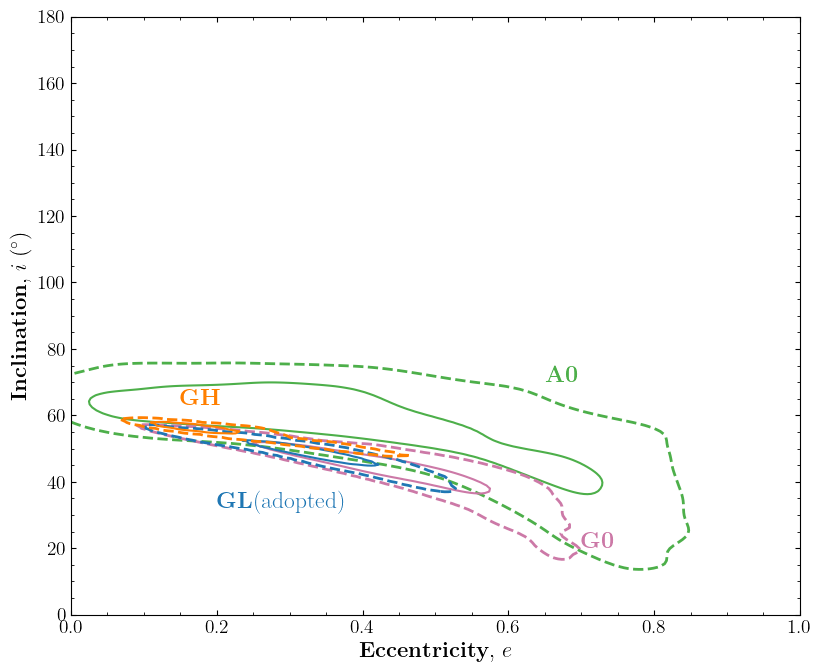

In [ ]:
#Figure 4
plt.rcParams.update({
    "text.usetex": True,  
    "font.family": "Fira Sans",  
    "font.size": 16,
    "axes.labelsize": 16,    
    "xtick.labelsize": 14,   
    "ytick.labelsize": 14,   
    "legend.fontsize": 13
})
from scipy.stats import gaussian_kde
files = {
    "GL": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5",
    "GH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_yes_gravity.hdf5",
    "G0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_yes_gravity.hdf5",
    "A0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_no_gravity.hdf5",
    "AL": "/Users/astrovidee/Dropbox//GQ_lup_b_analysis/new_runs/new_run_RV_no_gravity.hdf5",
    "AH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_no_gravity.hdf5"
}
ecc_data = {}
inc_data = {}
for label, file_path in files.items():
    with h5py.File(file_path, 'r') as f:
        data = f['post'][:]
        ecc_data[label] = data[:, 1]
        inc_data[label] = (data[:, 2] * u.rad).to(u.deg).value

# Colors
colors = {
    "A0": "#4daf4a",  # Green No RV no Grav
    "G0": "#CC79A7",  # Teal
    "GL": "#1f77b4",  # Blue 
    "GH": "#ff7f00"   # Orange
}

# Shared grid
x_grid = np.linspace(0, 1, 200)
y_grid = np.linspace(0, 180, 200)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])

# get sigma values
def get_sigma_levels(Z, X, Y, sigmas=[1, 2, 3]):
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    sorted_density = np.sort(Z.ravel())[::-1]
    cumsum = np.cumsum(sorted_density) * dx * dy
    cumsum /= cumsum[-1]
    levels = []
    for sigma in sigmas:
        prob = 1 - np.exp(-0.5 * sigma**2)
        idx = np.searchsorted(cumsum, prob)
        idx = min(idx, len(sorted_density) - 1)
        levels.append(sorted_density[idx])
    return sorted(levels)

fig, ax = plt.subplots(figsize=(8.5, 7))

# manual text add ins
label_positions = {
    "A0": (0.65, 70),
    "G0": (0.70, 20),
    "GL": (0.20, 32),
    "GH": (0.15, 63)
    
}

for label in ["A0", "G0", "GL", "GH"]:
    ecc = np.array(ecc_data[label])
    inc = np.array(inc_data[label])
    mask = np.isfinite(ecc) & np.isfinite(inc)
    ecc, inc = ecc[mask], inc[mask]

    if len(ecc) > 10000:
        idx = np.random.choice(len(ecc), 10000, replace=False)
        ecc, inc = ecc[idx], inc[idx]

    kde = gaussian_kde(np.vstack([ecc, inc]))
    Z = kde(positions).reshape(X.shape)
    levels = get_sigma_levels(Z, X, Y, sigmas=[1, 2, 3])

    # Plot 2sigma and 3sigma errors
    ax.contour(X, Y, Z, levels=[levels[1]], colors=colors[label], linewidths=2, linestyles='--')
    ax.contour(X, Y, Z, levels=[levels[2]], colors=colors[label], linewidths=1.5)

    
for label in ["A0", "G0", "GL", "GH"]:
    xpos, ypos = label_positions[label]
    if label == "GL":
        ax.text(xpos, ypos, r"\textbf{GL}(adopted)", fontsize=17, color=colors[label])
    else:
        ax.text(xpos, ypos, rf"\textbf{{{label}}}", fontsize=17, color=colors[label])
ax.set_xlabel(r"\textbf{Eccentricity}, $e$")
ax.set_ylabel(r"\textbf{Inclination}, $i$ ($^\circ$)")
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.minorticks_on()
#save fig for paper pdf format 
plt.tight_layout()
plt.savefig("combined_contour.pdf", dpi=300, bbox_inches='tight')
plt.show()

[69.72204692 71.06997289 69.86017129 ... 74.47182719 64.96247724
 75.77551024]
[33.10949498 71.95564934 61.08974071 ... 63.9169584  77.71621075
 38.10180808]
[40.25201381 41.42158795 36.72471952 ... 40.73016054 35.00393386
 44.34443915]
[69.72204692 71.06997289 69.86017129 ... 74.47182719 64.96247724
 75.77551024]


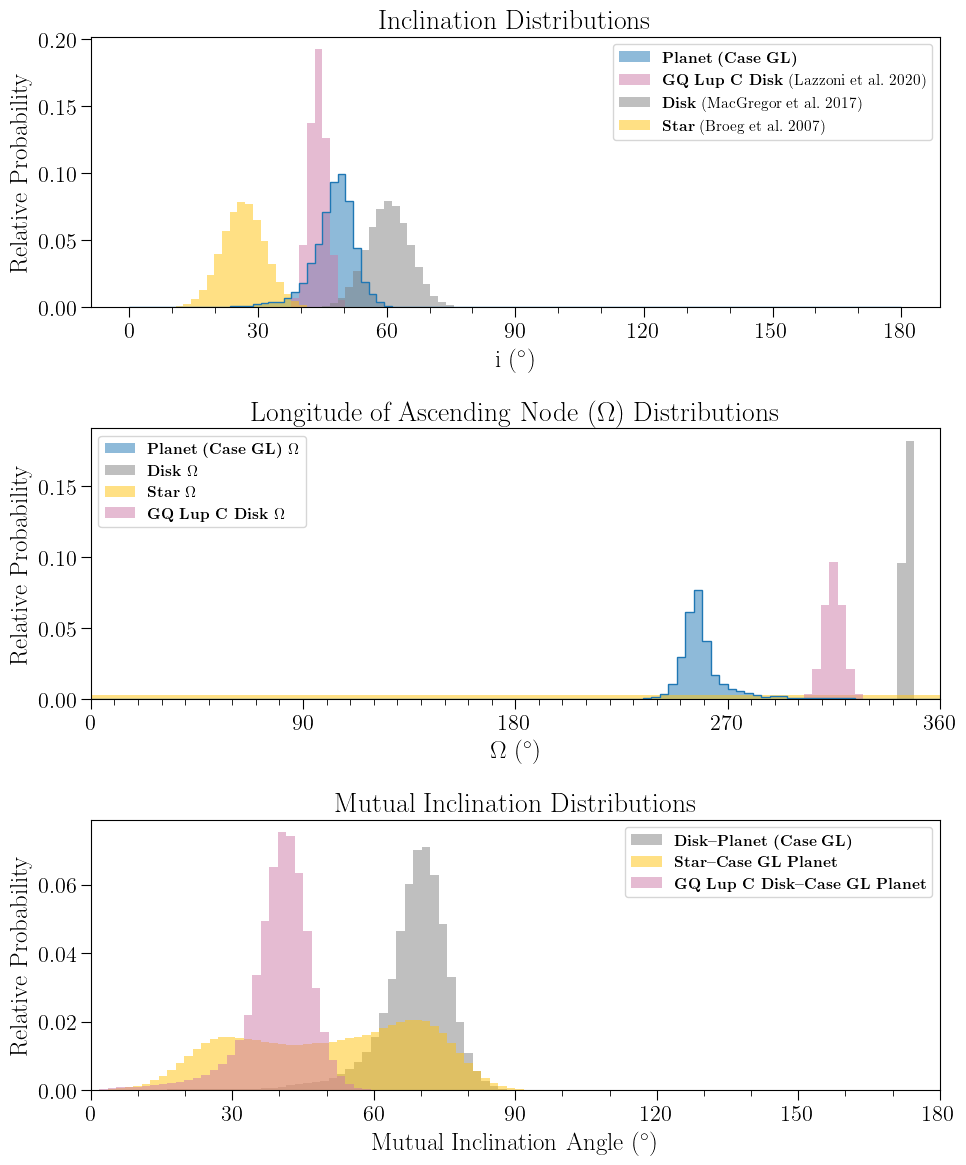

In [ ]:
#Figure 5
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from matplotlib.ticker import MultipleLocator

# Plotting styles
plt.rcParams.update({
    "text.usetex": True,  
    "font.family": "Fira Sans",  
    "font.size": 18,         
    "axes.titlesize": 20,    
    "axes.labelsize": 18,    
    "xtick.labelsize": 16,   
    "ytick.labelsize": 16,   
    "legend.fontsize": 16    
})

# File paths for fit 6
files = { 
    "RV + yes_grav": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5"
}

# Read inclination data
inc_data = {}
omega_rad = {}
dataset_path = "post"

for label, file_path in files.items():
    with h5py.File(file_path, 'r') as f:
        data = f[dataset_path][:]  
        inc = data[:, 2]  
        omega_rad = data[:, 4]
        omega_degrees = (omega_rad * u.rad).to(u.deg).value
        inc_degrees = (inc * u.rad).to(u.deg).value  
        inc_data[label] = inc_degrees  

# Random samples
np.random.seed(42)
N = 2000000
i0 = np.radians(inc_data["RV + yes_grav"])

# Get disk and star inclinations with uncertainties
disk_incl = np.random.normal(loc=60.5, scale=5, size=N)  #scale=0.5
star_incl = np.random.normal(loc=26.6, scale=5, size=N)   #scale=4.8
i_disk = np.radians(disk_incl)
i_star = np.radians(star_incl)
i_c = np.radians(np.random.normal(44,2,N)) #GQ Lup C

# Get Omegas
omega_0 = np.radians(np.random.choice(omega_degrees, size=N, replace=True))     
omega_star = np.radians(np.random.uniform(0, 360, N))   
omega_disk = np.radians(np.random.normal(346, 1, N))    
omega_c= np.radians(np.random.normal(315,4,N)) #position angle
# Calculate angular difference 
def angular_difference(a, b):
    return (a - b + np.pi) % (2 * np.pi) - np.pi

# Compute Misalignment Angle θ from Bowler paper
def compute_cos(i0, i_d, omega_0, omega_d):
    return np.cos(i0) * np.cos(i_d) + np.sin(i0) * np.sin(i_d) * np.cos(omega_0 - omega_d)

cos_theta_disk = compute_cos(i0, i_disk, omega_0, omega_disk)
cos_theta_star = compute_cos(i0, i_star, omega_0, omega_star)
cos_theta_c=compute_cos(i0,i_c,omega_0,omega_c)

theta_deg_disk = np.degrees(np.arccos(np.clip(cos_theta_disk, -1.0, 1.0)))
theta_deg_star = np.degrees(np.arccos(np.clip(cos_theta_star, -1.0, 1.0)))
theta_deg_c=np.degrees(np.arccos(np.clip(cos_theta_c,-1.0,1.0)))
print(theta_deg_disk)
print(theta_deg_star)
print(theta_deg_c)

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=False)
# Updated color map
colors = {
    "planet": "#1f77b4",  # Blue
    "star": "#FFC20A",    # Yellow
    "disk": "gray"        # Gray
}


# Inclination distributions
# Case GL Planet
axs[0].hist(np.degrees(i0), bins=100, range=(0, 180), density=True,
            histtype='stepfilled', alpha=0.5, color=colors['planet'], label=r'\textbf{Planet (Case GL)}')
axs[0].hist(np.degrees(i0), bins=100, range=(0, 180), density=True,
            histtype='step', color=colors['planet'])

# GQ Lup C

axs[0].hist(np.degrees(i_c), bins=100, range=(0, 180), density=True,
            histtype='stepfilled', color='#CC79A7', alpha=0.5,label=r'\textbf{GQ Lup C Disk} (Lazzoni et al.\ 2020)')

# Disk
axs[0].hist(disk_incl, bins=100, range=(0, 180), density=True,
            histtype='stepfilled', color=colors["disk"], alpha=0.5,label=r'\textbf{Disk} (MacGregor et al.\ 2017)')
# Star
axs[0].hist(star_incl, bins=100, range=(0, 180), density=True,
            histtype='stepfilled', color=colors["star"], alpha=0.5,label=r'\textbf{Star} (Broeg et al.\ 2007)')
axs[0].set_xlabel("i ($^\circ$)")
axs[0].set_ylabel("Relative Probability")
axs[0].set_title("Inclination Distributions")
# Set ticks
axs[0].xaxis.set_major_locator(MultipleLocator(30))
axs[0].xaxis.set_minor_locator(MultipleLocator(10)) 
axs[0].tick_params(which='major', length=7)
axs[0].tick_params(which='minor', length=4)
axs[0].legend(loc='upper right', fontsize=11)
#axs[0].grid(True, linestyle="--", alpha=0.5)

# Omega distributions
axs[1].hist(np.degrees(omega_0), histtype='stepfilled',bins=100, range=(0, 360), density=True, alpha=0.5, color=colors["planet"], label=r'\textbf{Planet (Case GL) $\Omega$}')
axs[1].hist(np.degrees(omega_0), bins=100, range=(0, 360), density=True,
            histtype='step', color=colors["planet"])

axs[1].hist(np.degrees(omega_disk), histtype='stepfilled',bins=100, range=(0, 360), density=True, alpha=0.5, color=colors["disk"], label=r'\textbf{Disk $\Omega$}')
axs[1].hist(np.degrees(omega_star), histtype='stepfilled',bins=100, range=(0, 360), density=True, alpha=0.5, color=colors["star"], label=r'\textbf{Star $\Omega$}')
axs[1].hist(np.degrees(omega_c), histtype='stepfilled',bins=100, range=(0, 360), density=True, alpha=0.5, color='#CC79A7', label=r'\textbf{GQ Lup C Disk $\Omega$}')
axs[1].set_xlim(0, 360)

axs[1].set_ylabel("Relative Probability")
axs[1].set_xlabel("$\Omega$ ($^\circ$)")
axs[1].set_title("Longitude of Ascending Node ($\Omega$) Distributions")
axs[1].legend(loc='upper left', fontsize=11)
axs[1].xaxis.set_major_locator(MultipleLocator(90))
axs[1].xaxis.set_minor_locator(MultipleLocator(10)) 
axs[1].tick_params(which='major', length=7)
axs[1].tick_params(which='minor', length=4)
##axs[1].grid(True, linestyle="--", alpha=0.5)

# Mutual inclination distributions
axs[2].hist(theta_deg_disk, bins=100, histtype='stepfilled',range=(0, 180), density=True, alpha=0.5, color=colors["disk"], label=r'\textbf{Disk–Planet (Case GL)}')
axs[2].hist(theta_deg_star, bins=100, histtype='stepfilled',range=(0, 180), density=True, alpha=0.5, color=colors["star"], label=r'\textbf{Star–Case GL Planet}')
axs[2].hist(theta_deg_c, bins=100, histtype='stepfilled',range=(0, 180), density=True, alpha=0.5, color='#CC79A7', label=r'\textbf{GQ Lup C Disk–Case GL Planet}')
axs[2].set_xlim(0, 180)
print(theta_deg_disk)
axs[2].set_xlabel("Mutual Inclination Angle ($^\circ$)")
axs[2].set_ylabel("Relative Probability")
axs[2].set_title("Mutual Inclination Distributions")
axs[2].legend(loc='upper right', fontsize=11)
axs[2].xaxis.set_major_locator(MultipleLocator(30))
axs[2].xaxis.set_minor_locator(MultipleLocator(10)) 
axs[2].tick_params(which='major', length=7)
axs[2].tick_params(which='minor', length=4)
#axs[2].grid(True, linestyle="--", alpha=0.5)

#save plot for the paper.
plt.tight_layout()
plt.savefig('mutual_inclination_3panel.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#Make the table 
from orbitize import results
import numpy as np

column_labels = ["A0", "G0", "AL", "AH", "GL", "GH"]
hdf5_file_paths = {
    "GL": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_yes_gravity.hdf5",
    "GH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_yes_gravity.hdf5",
    "G0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_yes_gravity.hdf5",
    "A0": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_no_RV_no_gravity.hdf5",
    "AL": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_no_gravity.hdf5",
    "AH": "/Users/astrovidee/Dropbox/GQ_lup_b_analysis/new_runs/new_run_RV_better_no_gravity.hdf5"
}

# Parameter names to extract and display
param_labels = ["sma1", "ecc1", "inc1", "aop1", "pan1", "tau1", "plx", "mtot"]
param_display_names = [
    "SMA [au]", "$e$", "$i$ [deg]", r"$\omega_0$ [deg]",
    r"$\Omega_0$ [deg]", r"$\tau_0$", r"$\pi$ [mas]", r"$M_\mathrm{tot}$ [$M_\odot$]"
]

import numpy as np

def format_row(samples, labels_list, param_order):
    row = []
    label_to_index = {label: i for i, label in enumerate(labels_list)}
    for param in param_order:
        idx = label_to_index[param]
        param_samples = samples[:, idx]
        
        # Convert angular parameters from radians to degrees
        if param in ["inc1", "aop1", "pan1"]:
            param_samples = np.degrees(param_samples)
        
        median = np.percentile(param_samples, 50)
        low = median - np.percentile(param_samples, 16)
        high = np.percentile(param_samples, 84) - median
        row.append(f"${median:.2f}^{{+{high:.2f}}}_{{-{low:.2f}}}$")
    return row


# Gather values for each file
param_values = {}
for label, path in hdf5_file_paths.items():
    res = results.Results()
    res.load_results(path)
    samples = res.post  # shape (n_samples, n_params)
    labels_list = res.labels  # list of parameter names
    param_values[label] = format_row(samples, labels_list, param_labels)

# Generate LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{@{} l" + "c" * len(column_labels) + " @{} }")
print("\\toprule")
print("\\textbf{Parameter} & " + " & ".join([f"\\textbf{{{lbl}}}" for lbl in column_labels]) + " \\\\")
print("\\midrule")
for i, name in enumerate(param_display_names):
    row = [param_values[col][i] for col in column_labels]
    print(f"{name} & " + " & ".join(row) + " \\\\")
print("\\bottomrule")
print("\\end{tabular}%")
print("}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{@{} lcccccc @{} }
\toprule
\textbf{Parameter} & \textbf{A0} & \textbf{G0} & \textbf{AL} & \textbf{AH} & \textbf{GL} & \textbf{GH} \\
\midrule
SMA [au] & $112.45^{+74.30}_{-34.25}$ & $98.94^{+11.43}_{-10.80}$ & $112.97^{+28.38}_{-22.17}$ & $114.25^{+22.93}_{-17.61}$ & $97.71^{+8.92}_{-7.14}$ & $106.55^{+5.59}_{-5.53}$ \\
$e$ & $0.46^{+0.27}_{-0.29}$ & $0.47^{+0.14}_{-0.16}$ & $0.28^{+0.31}_{-0.19}$ & $0.21^{+0.32}_{-0.15}$ & $0.35^{+0.10}_{-0.09}$ & $0.20^{+0.14}_{-0.06}$ \\
$i$ [deg] & $57.43^{+9.40}_{-19.18}$ & $43.52^{+6.42}_{-9.62}$ & $59.24^{+5.60}_{-8.22}$ & $59.73^{+4.97}_{-6.16}$ & $48.18^{+3.71}_{-4.93}$ & $55.67^{+1.45}_{-4.32}$ \\
$\omega_0$ [deg] & $190.94^{+96.26}_{-134.68}$ & $196.51^{+20.05}_{-23.57}$ & $166.23^{+116.69}_{-69.14}$ & $164.14^{+132.94}_{-57.28}$ & $175.82^{+9.66}_{-24.05}$ & $161.25^{+13.53}_{-37.91}$ \\
$\Omega_0$ [deg] & $199.04^{+69.34}_{-135.95}$ & $241.01^{+15.53}_{-23.66}$ & $26